In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('vgsales.csv')

In [7]:
df.head(5)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [12]:
df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')

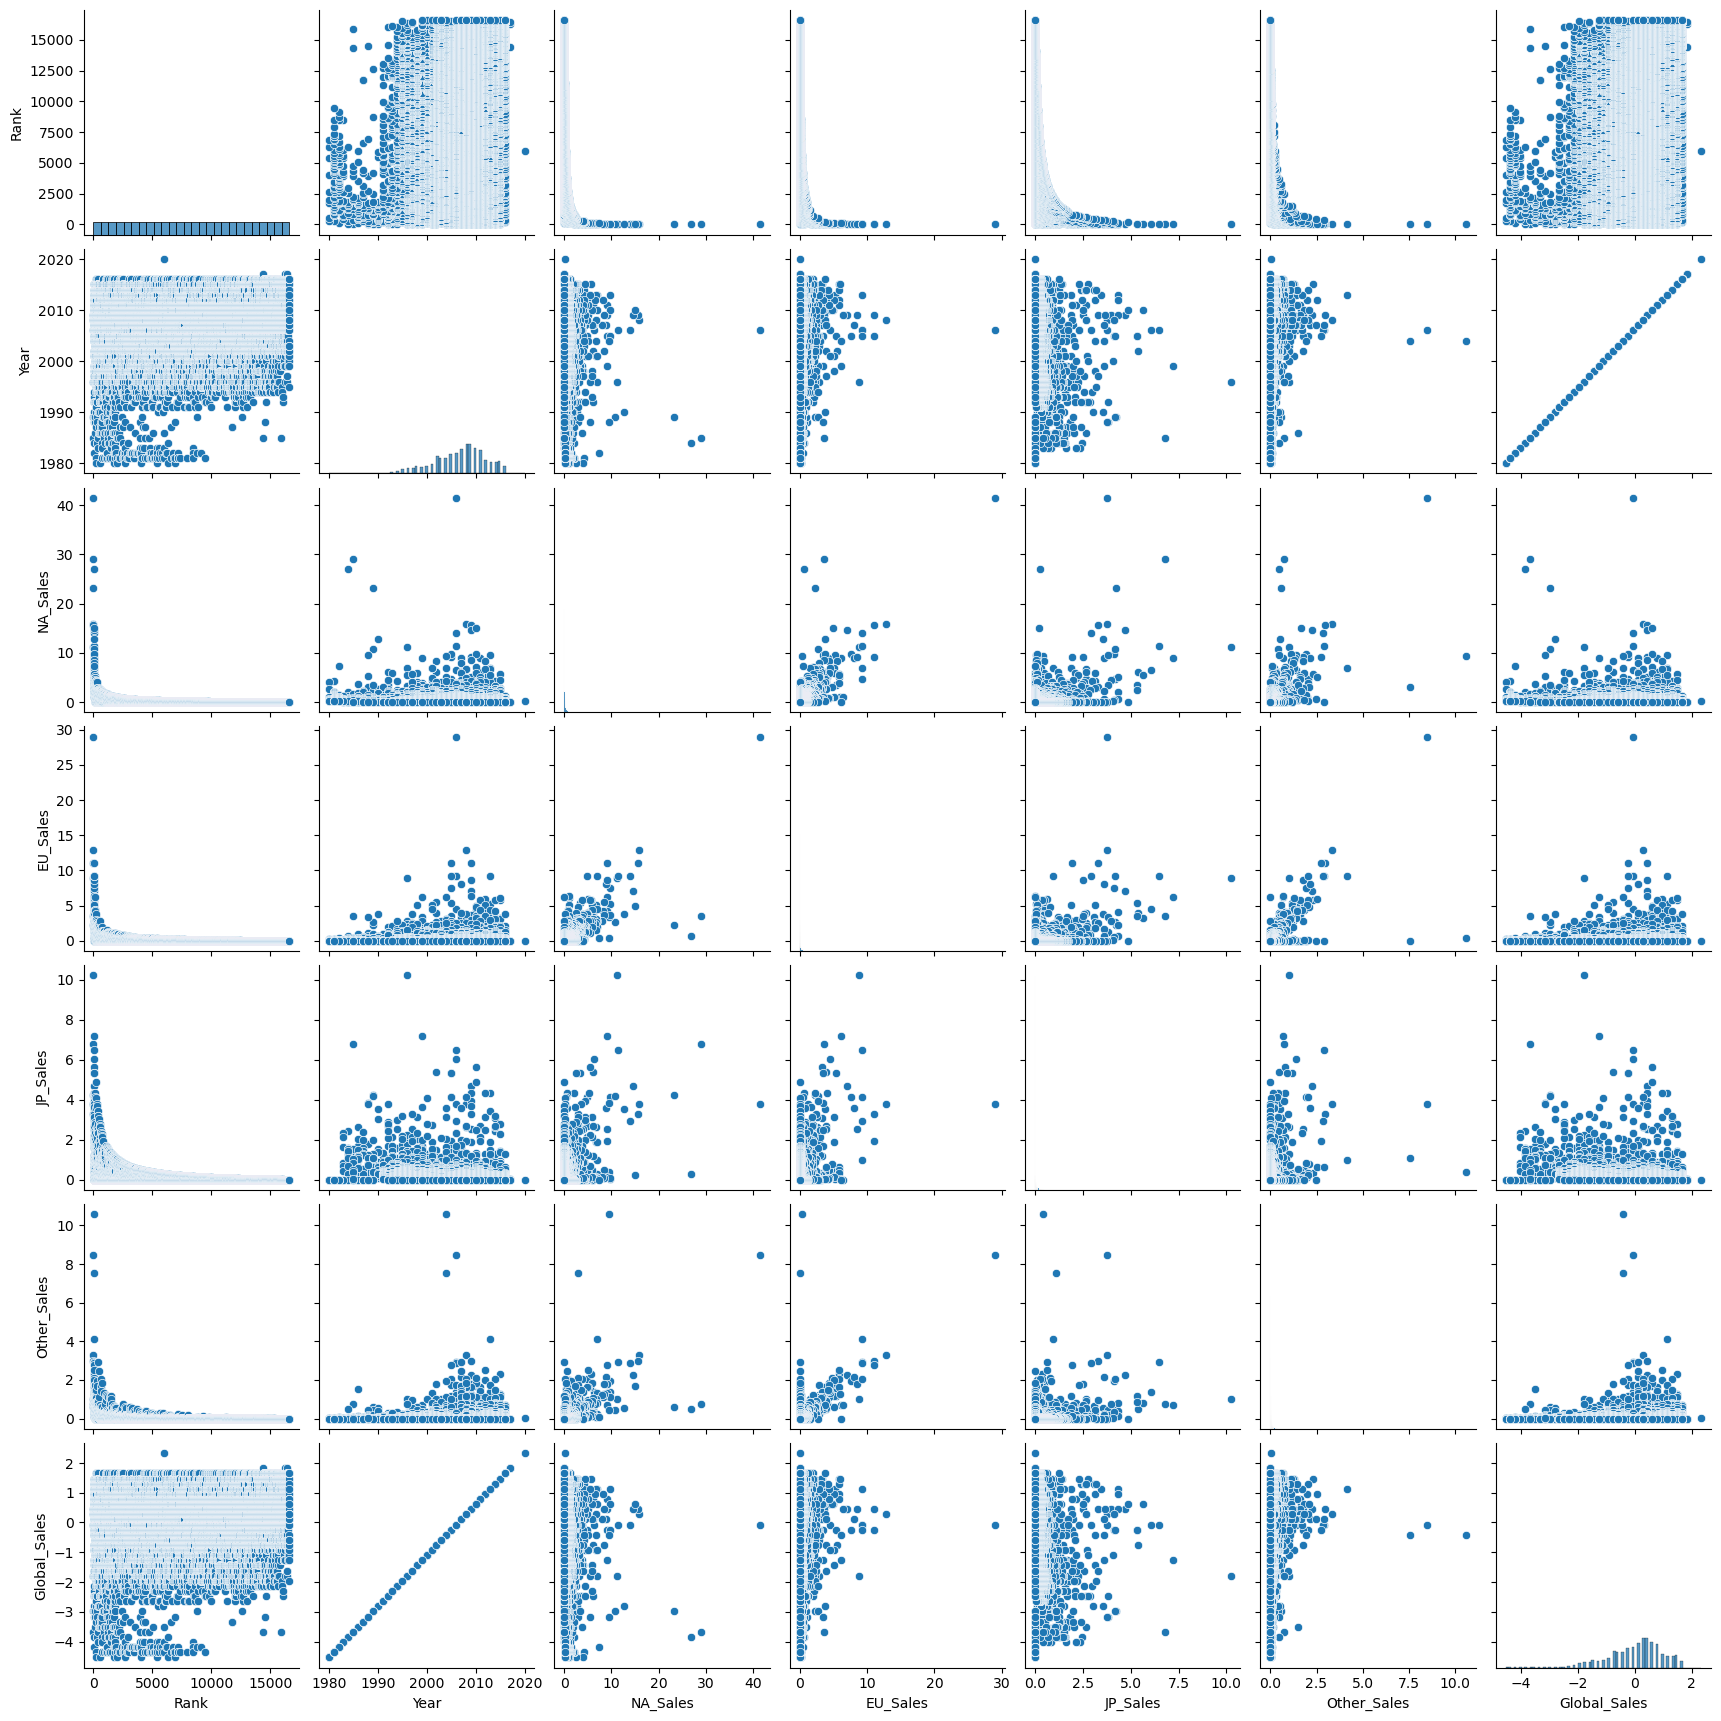

In [32]:
sns.pairplot(df)

C:\Users\admin\AppData\Local\Temp\ipykernel_4852\58359773.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr())


<Axes: >

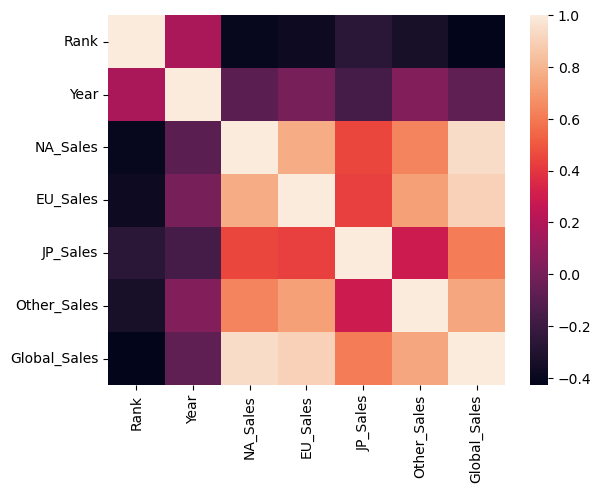

In [9]:
sns.heatmap(df.corr())

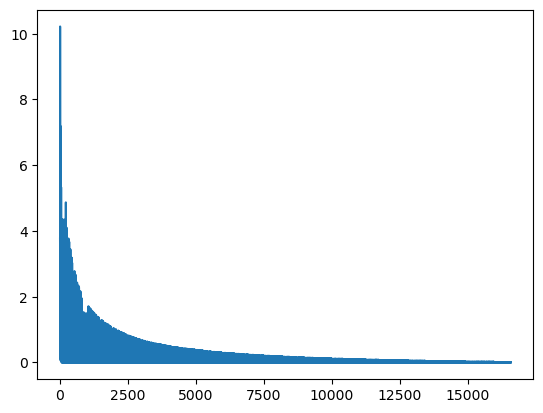

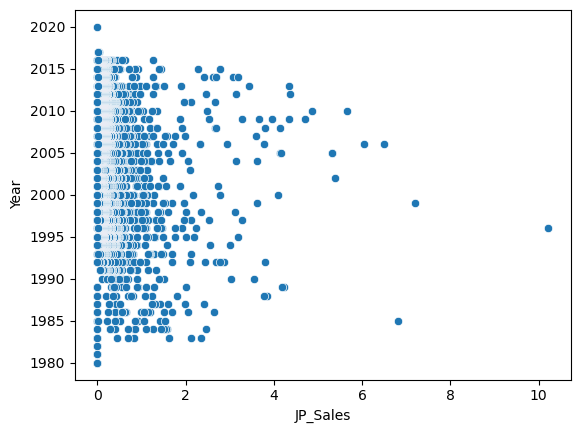

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a histogram of a continuous variable (e.g., 'Age')
plt.plot(df['JP_Sales'])
plt.show()

# Create a scatter plot to see the relationship between two variables
sns.scatterplot(x='JP_Sales', y='Year', data=df)
plt.show()

In [21]:
sns.histplot(df['EU_Sales'], df['JP_Sales'])
plt.show()

TypeError: histplot() takes from 0 to 1 positional arguments but 2 were given

In [16]:
from sklearn.preprocessing import StandardScaler

# Replace missing values with the mean
df['EU_Sales'].fillna(df['EU_Sales'].mean(), inplace=True)

# Scale a continuous variable 
scaler = StandardScaler()
df['Global_Sales'] = scaler.fit_transform(df[['Year']])

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X = df[['EU_Sales']] 
y = df['JP_Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


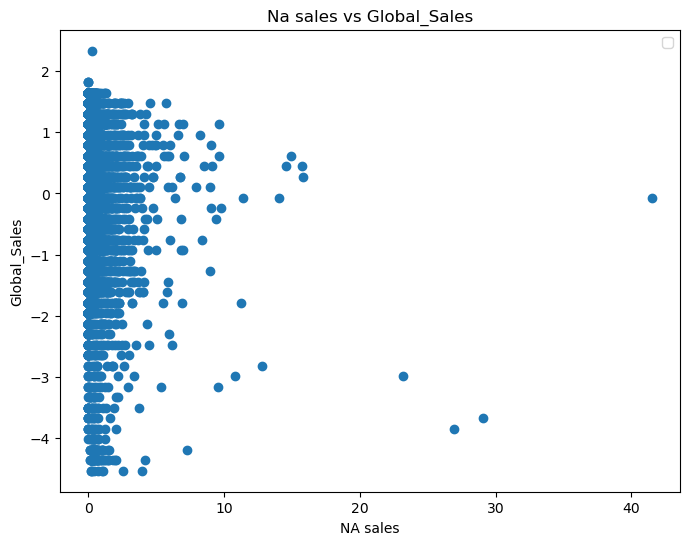

In [24]:
plt.figure(figsize = (8,6))
plt.scatter(df['NA_Sales'], df['Global_Sales'])
plt.title('Na sales vs Global_Sales')
plt.xlabel('NA sales')
plt.ylabel('Global_Sales')
plt.legend()
plt.show()

Trend line equation: y = 1.95x + 0.05


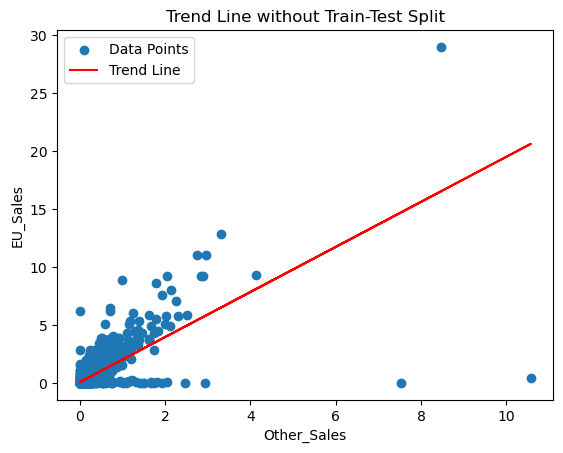

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Assuming your DataFrame is named 'df'
# Replace 'your_x_column' and 'your_y_column' with the actual column names
x_column = 'Other_Sales'  
y_column = 'EU_Sales'

# Create a linear regression model
model = LinearRegression()

# Fit the model to the entire dataset
X = df[[x_column]]  # Use the actual column name for x
y = df[y_column]    # Use the actual column name for y
model.fit(X, y)

# Get the coefficients of the trend line
slope = model.coef_[0]
intercept = model.intercept_

# Print the equation of the trend line
print(f"Trend line equation: y = {slope:.2f}x + {intercept:.2f}")

# Plot the data points and the trend line
plt.scatter(df[x_column], df[y_column], label='Data Points')  # Use actual column names
plt.plot(df[x_column], model.predict(X), color='red', label='Trend Line')
plt.xlabel(x_column)  # Use actual column name for x-axis label
plt.ylabel(y_column)  # Use actual column name for y-axis label
plt.title('Trend Line without Train-Test Split')
plt.legend()
plt.show()